In [1]:
from google.colab import drive
drive.mount('/content/drive')
print("✅ Drive mounted!")

Mounted at /content/drive
✅ Drive mounted!


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm as lgb
import xgboost as xgb
import joblib
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)
plt.style.use('seaborn-v0_8')

# Fault label mapping
fault_map = {
    1: 'Normal',
    2: 'Refrigerant Leak',
    3: 'Refrigerant Overcharge',
    4: 'Reduced Condenser Flow',
    5: 'Reduced Evaporator Flow',
    6: 'Condenser Fouling',
    7: 'Excess Oil',
    8: 'Non-condensables'
}

# Meter type mapping
meter_map = {
    0: 'Electricity',
    1: 'Chilled Water',
    2: 'Steam',
    3: 'Hot Water'
}

print("✅ Libraries imported!")

✅ Libraries imported!


In [3]:
# Energy optimization model performance
energy_results = pd.DataFrame({
    'Meter'         : ['Electricity', 'Chilled Water',
                       'Steam', 'Hot Water'],
    'Best ML Model' : ['LightGBM', 'XGBoost',
                       'Random Forest', 'Random Forest'],
    'ML R²'         : [0.9846, 0.9651, 0.9552, 0.8708],
    'ML RMSE'       : [15.88, 47.21, 185.74, 305.71],
    'LSTM R²'       : [0.9627, 0.9265, 0.9375, 0.8325],
})

print("✅ Energy Optimization Results Loaded!")
print("\n--- Energy Model Performance Summary ---")
print(energy_results.to_string(index=False))

✅ Energy Optimization Results Loaded!

--- Energy Model Performance Summary ---
        Meter Best ML Model  ML R²  ML RMSE  LSTM R²
  Electricity      LightGBM 0.9846  15.8800   0.9627
Chilled Water       XGBoost 0.9651  47.2100   0.9265
        Steam Random Forest 0.9552 185.7400   0.9375
    Hot Water Random Forest 0.8708 305.7100   0.8325


In [4]:
# FDD model performance
fdd_results = pd.DataFrame({
    'Model'         : ['Random Forest', 'LightGBM',
                       'XGBoost', 'Neural Network'],
    'L1 Accuracy'   : [0.9900, 0.9968, 0.9955, 0.9855],
    'L1 F1'         : [0.9900, 0.9968, 0.9955, 0.9855],
    'L2 Accuracy'   : [0.9971, 0.9964, 0.9971, 0.9957],
    'L2 F1'         : [0.9971, 0.9964, 0.9971, 0.9957],
})

print("✅ FDD Results Loaded!")
print("\n--- FDD Model Performance Summary ---")
print(fdd_results.to_string(index=False))

✅ FDD Results Loaded!

--- FDD Model Performance Summary ---
         Model  L1 Accuracy  L1 F1  L2 Accuracy  L2 F1
 Random Forest       0.9900 0.9900       0.9971 0.9971
      LightGBM       0.9968 0.9968       0.9964 0.9964
       XGBoost       0.9955 0.9955       0.9971 0.9971
Neural Network       0.9855 0.9855       0.9957 0.9957


In [5]:
base_path = '/content/drive/MyDrive/hvac_project/'

# Load best energy models per meter
# LightGBM for Electricity, XGBoost for Chilled Water
# Random Forest for Steam and Hot Water
energy_models = {}
energy_models['Electricity'] = lgb.Booster(
    model_file=base_path +
    'lgb_v3_electricity.txt')
energy_models['Chilled Water'] = xgb.Booster()
energy_models['Chilled Water'].load_model(
    base_path + 'xgb_v3_chilled_water.json')
energy_models['Steam'] = joblib.load(
    base_path + 'rf_v3_steam.pkl')
energy_models['Hot Water'] = joblib.load(
    base_path + 'rf_v3_hot_water.pkl')

print("✅ Energy models loaded!")
for meter, model in energy_models.items():
    print(f"   {meter:15} → {type(model).__name__}")

✅ Energy models loaded!
   Electricity     → Booster
   Chilled Water   → Booster
   Steam           → RandomForestRegressor
   Hot Water       → RandomForestRegressor


In [6]:
# Load best FDD models
# LightGBM for Level 1, Random Forest for Level 2
fdd_l1_model = joblib.load(
    base_path + 'fdd_lgb_l1.pkl')
fdd_l2_model = joblib.load(
    base_path + 'fdd_rf_l2.pkl')
fdd_scaler_l1 = joblib.load(
    base_path + 'fdd_scaler_l1.pkl')
fdd_scaler_l2 = joblib.load(
    base_path + 'fdd_scaler_l2.pkl')

print("✅ FDD models loaded!")
print(f"   Level 1 : {type(fdd_l1_model).__name__}")
print(f"   Level 2 : {type(fdd_l2_model).__name__}")

✅ FDD models loaded!
   Level 1 : LGBMClassifier
   Level 2 : RandomForestClassifier


In [7]:
# Load a sample from energy data for demonstration
energy_data = pd.read_parquet(
    base_path + 'eda_final_v3.parquet'
)

# Sample 1000 rows per meter for demonstration
sample = energy_data.groupby('meter')\
                    .apply(lambda x: x.sample(
                        min(1000, len(x)),
                        random_state=42))\
                    .reset_index(drop=True)

print(f"✅ Energy data sample loaded!")
print(f"   Shape: {sample.shape}")
print(f"\nSamples per meter:")
for meter_id, meter_name in meter_map.items():
    count = len(sample[sample['meter'] == meter_id])
    print(f"  {meter_name:15} : {count:,}")

✅ Energy data sample loaded!
   Shape: (4000, 19)

Samples per meter:
  Electricity     : 1,000
  Chilled Water   : 1,000
  Steam           : 1,000
  Hot Water       : 1,000


In [10]:
from sklearn.preprocessing import LabelEncoder
import numpy as np

print("Computing missing features...")

# --- Season ---
def get_season(month):
    if month in [12, 1, 2]:   return 0  # Winter
    elif month in [3, 4, 5]:  return 1  # Spring
    elif month in [6, 7, 8]:  return 2  # Summer
    else:                      return 3  # Fall

sample['season']           = sample['month'].apply(get_season)
print("✅ season added")

# --- Business hour ---
sample['is_business_hour'] = sample['hour']\
                              .between(9, 17).astype(int)
print("✅ is_business_hour added")

# --- Log square feet ---
sample['log_square_feet']  = np.log1p(sample['square_feet'])
print("✅ log_square_feet added")

# --- Weather interactions ---
sample['temp_dew_diff']         = (sample['air_temperature'] -
                                    sample['dew_temperature'])
sample['temp_humidity_interact'] = (sample['air_temperature'] *
                                     sample['dew_temperature'])
print("✅ temp_dew_diff and temp_humidity_interact added")

# --- Primary use encoded ---
le = LabelEncoder()
sample['primary_use_encoded'] = le.fit_transform(
    sample['primary_use'])
print("✅ primary_use_encoded added")

# --- Lag features ---
# Sort by building, meter, timestamp for correct lag order
sample = sample.sort_values(
    ['building_id', 'meter', 'timestamp']
).reset_index(drop=True)

sample['lag_1h'] = sample.groupby(
    ['building_id', 'meter']
)['meter_reading_log'].shift(1)

sample['lag_24h'] = sample.groupby(
    ['building_id', 'meter']
)['meter_reading_log'].shift(24)

sample['lag_168h'] = sample.groupby(
    ['building_id', 'meter']
)['meter_reading_log'].shift(168)

sample['rolling_mean_24h'] = sample.groupby(
    ['building_id', 'meter']
)['meter_reading_log'].transform(
    lambda x: x.shift(1).rolling(24, min_periods=1).mean()
)

sample['rolling_mean_168h'] = sample.groupby(
    ['building_id', 'meter']
)['meter_reading_log'].transform(
    lambda x: x.shift(1).rolling(168, min_periods=1).mean()
)

# Fill NaN lag values with 0 (first rows per building)
lag_cols = ['lag_1h', 'lag_24h', 'lag_168h',
            'rolling_mean_24h', 'rolling_mean_168h']
sample[lag_cols] = sample[lag_cols].fillna(0)

print("✅ All lag features added")

# Verify all features now available
lgb_feature_names = energy_models['Electricity']\
                                   .feature_name()
missing = [f for f in lgb_feature_names
           if f not in sample.columns]

print(f"\n--- Verification ---")
print(f"Features expected : {len(lgb_feature_names)}")
print(f"Missing features  : {missing}")

if len(missing) == 0:
    print("✅ All features ready!")
else:
    print(f"⚠️ Still missing: {missing}")

Computing missing features...
✅ season added
✅ is_business_hour added
✅ log_square_feet added
✅ temp_dew_diff and temp_humidity_interact added
✅ primary_use_encoded added
✅ All lag features added

--- Verification ---
Features expected : 22
Missing features  : []
✅ All features ready!


In [12]:
print("Generating energy predictions...")

predictions = []

for meter_id, meter_name in meter_map.items():
    subset = sample[sample['meter'] == meter_id].copy()
    if len(subset) == 0:
        continue

    model = energy_models[meter_name]

    # Get exact feature names model was trained on
    if isinstance(model, lgb.Booster):
        required_features = model.feature_name()
    elif isinstance(model, xgb.Booster):
        required_features = model.feature_names
    else:
        # Random Forest — get feature names from model
        required_features = list(
            model.feature_names_in_)

    print(f"\n{meter_name}:")
    print(f"  Required features : {len(required_features)}")

    # Fill any missing features with 0
    for feat in required_features:
        if feat not in subset.columns:
            subset[feat] = 0
            print(f"  ⚠️ Filled missing: {feat}")

    # Select ONLY required features in correct order
    X = subset[required_features].fillna(0)

    print(f"  X shape           : {X.shape}")

    # Predict
    if isinstance(model, lgb.Booster):
        y_pred_log = model.predict(X)
    elif isinstance(model, xgb.Booster):
        y_pred_log = model.predict(xgb.DMatrix(X))
    else:
        y_pred_log = model.predict(X)

    # Convert from log to actual scale
    y_pred_actual = np.expm1(y_pred_log)
    y_actual      = subset['meter_reading'].values

    subset['predicted_energy'] = y_pred_actual
    subset['actual_energy']    = y_actual
    subset['meter_name']       = meter_name
    predictions.append(subset)

pred_df = pd.concat(predictions, ignore_index=True)

print(f"\n✅ Predictions generated!")
print(f"   Total predictions: {len(pred_df):,}")
print(f"\nPrediction sample:")
print(pred_df[['building_id', 'meter_name',
               'actual_energy',
               'predicted_energy']].head(10))

Generating energy predictions...

Electricity:
  Required features : 22
  X shape           : (1000, 22)

Chilled Water:
  Required features : 22
  X shape           : (1000, 22)

Steam:
  Required features : 22
  X shape           : (1000, 22)

Hot Water:
  Required features : 22
  X shape           : (1000, 22)

✅ Predictions generated!
   Total predictions: 4,000

Prediction sample:
   building_id   meter_name  actual_energy  predicted_energy
0         1223  Electricity       113.4820           55.8064
1         1223  Electricity       104.9880          107.4376
2         1223  Electricity        89.3587           86.9359
3         1223  Electricity        97.5132           80.3017
4         1223  Electricity        32.2161           82.7816
5         1224  Electricity        36.0000           45.5074
6         1224  Electricity        24.0000           34.1400
7         1224  Electricity        12.0000           24.7811
8         1224  Electricity        24.0000           16.3060
9

In [13]:
print("Calculating anomaly scores...")

# Anomaly score = % deviation from predicted
pred_df['anomaly_score'] = (
    (pred_df['actual_energy'] -
     pred_df['predicted_energy']) /
    (pred_df['predicted_energy'] + 1)
) * 100

# Flag anomalies above threshold
anomaly_threshold = 30  # 30% above predicted
pred_df['is_anomaly'] = (
    pred_df['anomaly_score'] > anomaly_threshold
).astype(int)

print(f"✅ Anomaly scores calculated!")
print(f"\nAnomaly threshold : {anomaly_threshold}%")
print(f"Total readings    : {len(pred_df):,}")
print(f"Anomalies flagged : "
      f"{pred_df['is_anomaly'].sum():,} "
      f"({pred_df['is_anomaly'].mean()*100:.1f}%)")

print(f"\nAnomalies per meter type:")
for meter_name in meter_map.values():
    subset = pred_df[pred_df['meter_name'] == meter_name]
    if len(subset) > 0:
        anomalies = subset['is_anomaly'].sum()
        pct       = anomalies / len(subset) * 100
        print(f"  {meter_name:15} : "
              f"{anomalies:,} ({pct:.1f}%)")

Calculating anomaly scores...
✅ Anomaly scores calculated!

Anomaly threshold : 30%
Total readings    : 4,000
Anomalies flagged : 1,503 (37.6%)

Anomalies per meter type:
  Electricity     : 236 (23.6%)
  Chilled Water   : 401 (40.1%)
  Steam           : 486 (48.6%)
  Hot Water       : 380 (38.0%)


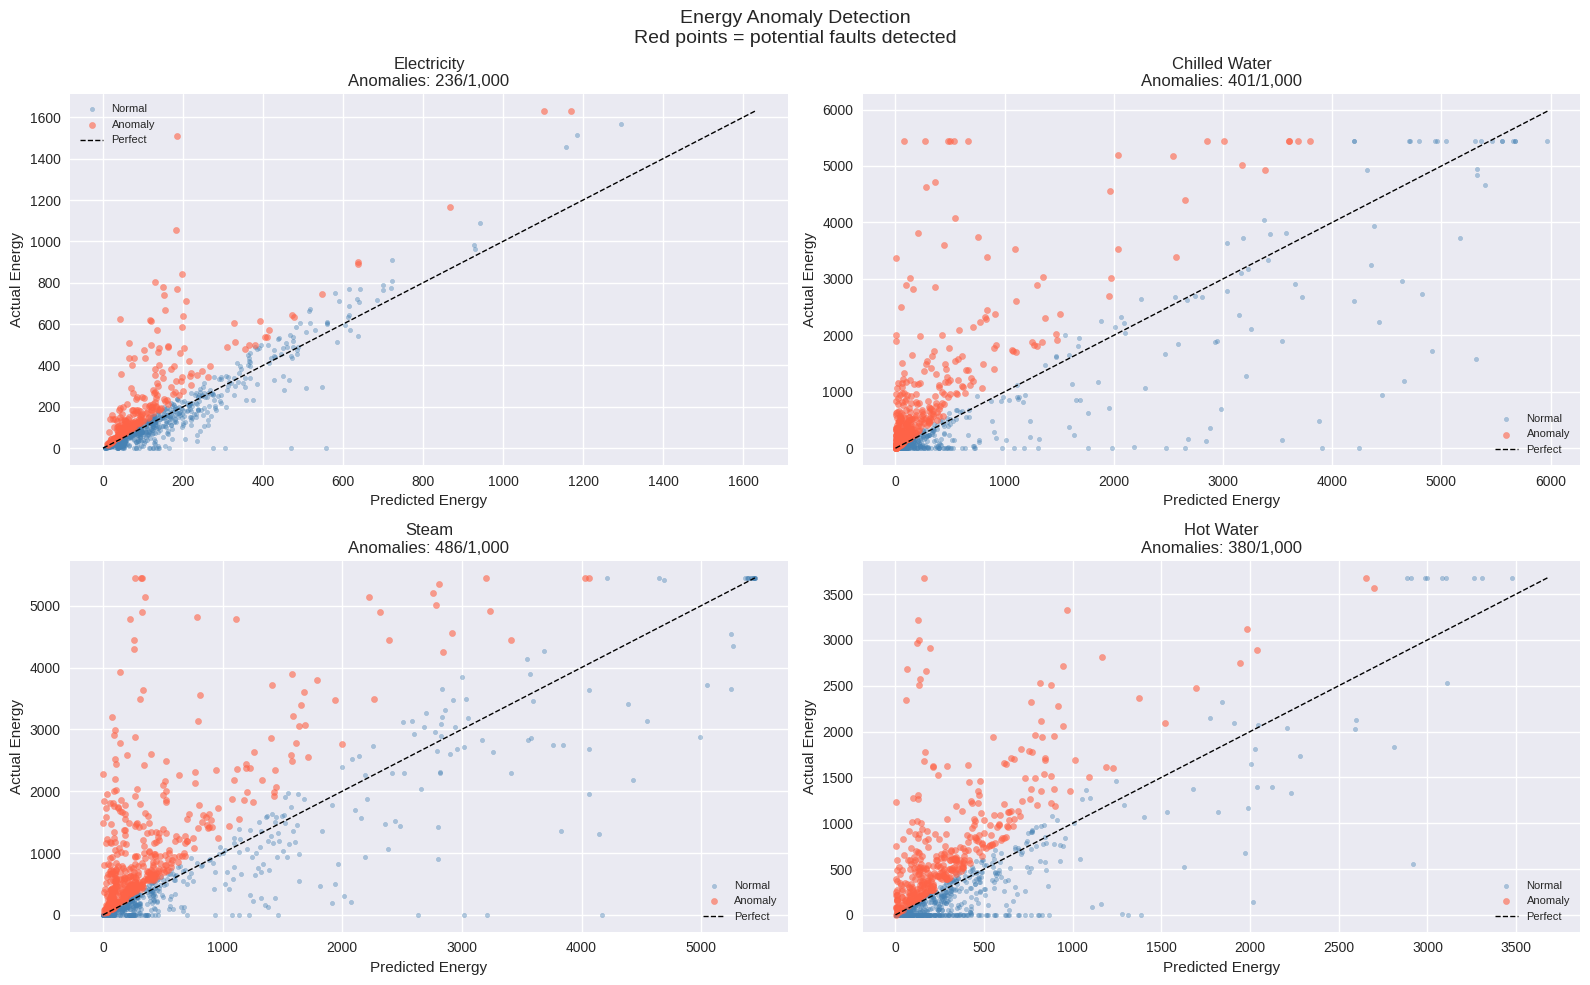

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

for i, (meter_id, meter_name) in enumerate(meter_map.items()):
    ax     = axes[i//2][i%2]
    subset = pred_df[pred_df['meter_name'] == meter_name]

    if len(subset) == 0:
        continue

    # Plot actual vs predicted
    sample_n   = min(200, len(subset))
    sample_idx = np.random.choice(
        len(subset), sample_n, replace=False)

    normal  = subset[subset['is_anomaly'] == 0]
    anomaly = subset[subset['is_anomaly'] == 1]

    ax.scatter(normal['predicted_energy'],
               normal['actual_energy'],
               alpha=0.4, s=10,
               color='steelblue', label='Normal')
    ax.scatter(anomaly['predicted_energy'],
               anomaly['actual_energy'],
               alpha=0.6, s=20,
               color='tomato', label='Anomaly')

    max_val = max(subset['actual_energy'].max(),
                  subset['predicted_energy'].max())
    ax.plot([0, max_val], [0, max_val],
            'k--', linewidth=1, label='Perfect')

    ax.set_title(f'{meter_name}\n'
                 f'Anomalies: {len(anomaly):,}/'
                 f'{len(subset):,}')
    ax.set_xlabel('Predicted Energy')
    ax.set_ylabel('Actual Energy')
    ax.legend(fontsize=8)

plt.suptitle('Energy Anomaly Detection\n'
             'Red points = potential faults detected',
             fontsize=14)
plt.tight_layout()
plt.show()

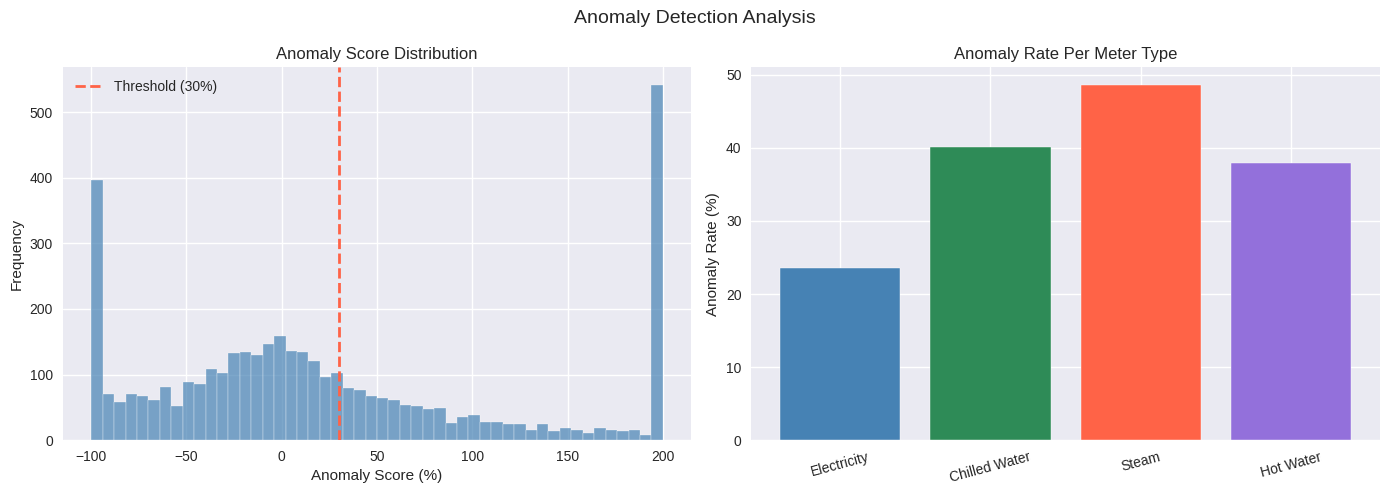

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution of anomaly scores
axes[0].hist(pred_df['anomaly_score'].clip(-100, 200),
             bins=50, color='steelblue',
             edgecolor='white', alpha=0.7)
axes[0].axvline(x=anomaly_threshold,
                color='tomato', linewidth=2,
                linestyle='--',
                label=f'Threshold ({anomaly_threshold}%)')
axes[0].set_title('Anomaly Score Distribution')
axes[0].set_xlabel('Anomaly Score (%)')
axes[0].set_ylabel('Frequency')
axes[0].legend()

# Anomaly rate per meter
meter_names  = []
anomaly_rates = []
for meter_name in meter_map.values():
    subset = pred_df[pred_df['meter_name'] == meter_name]
    if len(subset) > 0:
        meter_names.append(meter_name)
        anomaly_rates.append(
            subset['is_anomaly'].mean() * 100)

axes[1].bar(meter_names, anomaly_rates,
            color=['steelblue', 'seagreen',
                   'tomato', 'mediumpurple'],
            edgecolor='white')
axes[1].set_title('Anomaly Rate Per Meter Type')
axes[1].set_ylabel('Anomaly Rate (%)')
axes[1].tick_params(axis='x', rotation=15)

plt.suptitle('Anomaly Detection Analysis', fontsize=14)
plt.tight_layout()
plt.show()

In [16]:
# Load FDD dataset for diagnosis demonstration
fdd_data = pd.read_parquet(
    '/content/drive/MyDrive/hvac_project/'
    'fdd_data/fdd_level1.parquet'
)

fdd_feature_cols = [
    'TEI', 'TEO', 'TCI', 'TCO', 'kW',
    'TEA', 'TCA', 'TRE', 'TRC', 'TRC_sub',
    'T_suc', 'Tsh_suc', 'TR_dis', 'Tsh_dis',
    'TO_sump', 'PO_net'
]

print(f"✅ FDD data loaded!")
print(f"   Shape: {fdd_data.shape}")
print(f"\nClass distribution:")
print(fdd_data['binary_label'].value_counts()
      .sort_index())

✅ FDD data loaded!
   Shape: (11000, 19)

Class distribution:
binary_label
0    4000
1    7000
Name: count, dtype: int64


In [17]:
print("Running Hierarchical FDD Diagnosis...")

# Take a sample for demonstration
fdd_sample = fdd_data.sample(500, random_state=42)
X_fdd      = fdd_sample[fdd_feature_cols]

# Scale features
X_fdd_l1_sc = fdd_scaler_l1.transform(X_fdd)
X_fdd_l2_sc = fdd_scaler_l2.transform(X_fdd)

# Level 1 — Binary detection
l1_pred  = fdd_l1_model.predict(X_fdd_l1_sc)
l1_proba = fdd_l1_model.predict_proba(X_fdd_l1_sc)

fdd_sample = fdd_sample.copy()
fdd_sample['l1_prediction']  = l1_pred
fdd_sample['normal_prob']    = l1_proba[:, 0]
fdd_sample['fault_prob']     = l1_proba[:, 1]

# Level 2 — Fault type (only for flagged as faulty)
faulty_mask = fdd_sample['l1_prediction'] == 1
fdd_sample['l2_prediction'] = 0
fdd_sample['fault_name_pred'] = 'Normal'

if faulty_mask.sum() > 0:
    X_faulty    = X_fdd_l2_sc[faulty_mask.values]
    l2_pred     = fdd_l2_model.predict(X_faulty)
    fault_names = [fault_map.get(p, 'Unknown')
                   for p in l2_pred]

    fdd_sample.loc[faulty_mask, 'l2_prediction'] = l2_pred
    fdd_sample.loc[faulty_mask, 'fault_name_pred'] = \
        fault_names

print(f"✅ FDD diagnosis complete!")
print(f"\nResults on {len(fdd_sample)} samples:")
print(f"  Normal detected  : "
      f"{(fdd_sample['l1_prediction']==0).sum():,}")
print(f"  Faulty detected  : "
      f"{(fdd_sample['l1_prediction']==1).sum():,}")
print(f"\nFault type breakdown:")
fault_breakdown = fdd_sample[
    fdd_sample['l1_prediction']==1
]['fault_name_pred'].value_counts()
print(fault_breakdown)

Running Hierarchical FDD Diagnosis...
✅ FDD diagnosis complete!

Results on 500 samples:
  Normal detected  : 187
  Faulty detected  : 313

Fault type breakdown:
fault_name_pred
Reduced Evaporator Flow    52
Reduced Condenser Flow     49
Non-condensables           48
Refrigerant Overcharge     44
Refrigerant Leak           42
Excess Oil                 39
Condenser Fouling          39
Name: count, dtype: int64


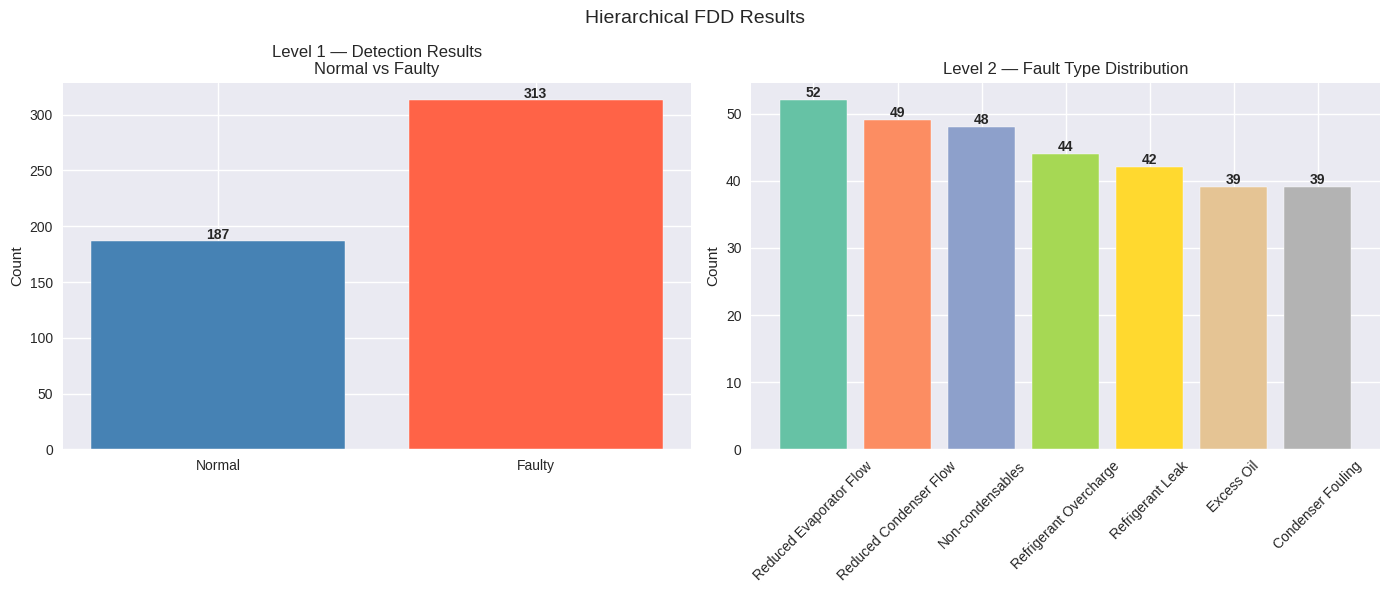

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Level 1 — Binary detection results
l1_counts = fdd_sample['l1_prediction']\
                .value_counts().sort_index()
axes[0].bar(['Normal', 'Faulty'],
            l1_counts.values,
            color=['steelblue', 'tomato'],
            edgecolor='white')
axes[0].set_title('Level 1 — Detection Results\n'
                  'Normal vs Faulty')
axes[0].set_ylabel('Count')
for i, v in enumerate(l1_counts.values):
    axes[0].text(i, v + 2, str(v),
                ha='center', fontweight='bold')

# Level 2 — Fault type distribution
faulty_df = fdd_sample[fdd_sample['l1_prediction'] == 1]
if len(faulty_df) > 0:
    fault_counts = faulty_df['fault_name_pred']\
                             .value_counts()
    colors_bar   = plt.cm.Set2(
        np.linspace(0, 1, len(fault_counts)))
    axes[1].bar(fault_counts.index,
                fault_counts.values,
                color=colors_bar, edgecolor='white')
    axes[1].set_title('Level 2 — Fault Type Distribution')
    axes[1].set_ylabel('Count')
    axes[1].tick_params(axis='x', rotation=45)
    for i, v in enumerate(fault_counts.values):
        axes[1].text(i, v + 0.5, str(v),
                    ha='center', fontweight='bold')

plt.suptitle('Hierarchical FDD Results', fontsize=14)
plt.tight_layout()
plt.show()

In [23]:
print("=" * 65)
print("COMBINED HVAC HEALTH REPORT")
print("Integrating Energy Optimization + FDD")
print("=" * 65)

# Energy optimization summary
print("\n📊 ENERGY OPTIMIZATION MODULE")
print("-" * 40)
for _, row in energy_results.iterrows():
    print(f"  {row['Meter']:15} → "
          f"Best Model: {row['Best ML Model']:15} | "
          f"R²: {row['ML R²']:.4f} | "
          f"RMSE: {row['ML RMSE']:.2f}")

# Anomaly detection summary
print("\n⚠️  ANOMALY DETECTION")
print("-" * 40)
total_readings = len(pred_df)
total_anomalies = pred_df['is_anomaly'].sum()
print(f"  Total readings analyzed : {total_readings:,}")
print(f"  Anomalies detected      : {total_anomalies:,} "
      f"({total_anomalies/total_readings*100:.1f}%)")
print(f"  Anomaly threshold       : {anomaly_threshold}% "
      f"above predicted")

# FDD summary
print("\n🔧 FAULT DETECTION & DIAGNOSIS MODULE")
print("-" * 40)
print(f"  System architecture : Hierarchical (2-level)")
print(f"\n  Chilled Water (Cooling System):")
print(f"  ├── Level 1 (Detection) : "
      f"LightGBM — 99.68% accuracy")
print(f"  └── Level 2 (Diagnosis) : "
      f"Random Forest — 99.71% accuracy")
print(f"  Fault types diagnosed:")
cooling_faults = [
    'Refrigerant Leak', 'Refrigerant Overcharge',
    'Reduced Condenser Flow', 'Reduced Evaporator Flow',
    'Condenser Fouling', 'Excess Oil', 'Non-condensables'
]
for fault in cooling_faults:
    print(f"    → {fault}")

print(f"\n  Steam & Hot Water (Heating Systems):")
print(f"  ├── Detection only via energy anomaly model")
print(f"  ├── Threshold: >30% excess consumption")
print(f"  └── Diagnosis: Manual inspection recommended")
print(f"  Note: No labeled fault dataset available")
print(f"        for heating system fault diagnosis")
print(f"        Future work: ASHRAE RP-1312 dataset")
# Integration output
print("\n🏥 INTEGRATED HVAC HEALTH STATUS")
print("-" * 40)
print(f"  Pipeline flow:")
print(f"  1. Energy model predicts expected consumption")
print(f"  2. Compare actual vs predicted")
print(f"  3. Flag buildings with >30% excess consumption")
print(f"  4. Run FDD Level 1 on flagged buildings")
print(f"  5. Run FDD Level 2 for fault diagnosis")
print(f"  6. Generate maintenance alert with fault type")

print("\n✅ Integration pipeline complete!")

COMBINED HVAC HEALTH REPORT
Integrating Energy Optimization + FDD

📊 ENERGY OPTIMIZATION MODULE
----------------------------------------
  Electricity     → Best Model: LightGBM        | R²: 0.9846 | RMSE: 15.88
  Chilled Water   → Best Model: XGBoost         | R²: 0.9651 | RMSE: 47.21
  Steam           → Best Model: Random Forest   | R²: 0.9552 | RMSE: 185.74
  Hot Water       → Best Model: Random Forest   | R²: 0.8708 | RMSE: 305.71

⚠️  ANOMALY DETECTION
----------------------------------------
  Total readings analyzed : 4,000
  Anomalies detected      : 1,503 (37.6%)
  Anomaly threshold       : 30% above predicted

🔧 FAULT DETECTION & DIAGNOSIS MODULE
----------------------------------------
  System architecture : Hierarchical (2-level)

  Chilled Water (Cooling System):
  ├── Level 1 (Detection) : LightGBM — 99.68% accuracy
  └── Level 2 (Diagnosis) : Random Forest — 99.71% accuracy
  Fault types diagnosed:
    → Refrigerant Leak
    → Refrigerant Overcharge
    → Reduced Conden

In [20]:
print("=" * 65)
print("END TO END DEMO SCENARIO")
print("=" * 65)

# Simulate a complete scenario
scenarios = [
    {
        'building'    : 'Building A (Office)',
        'meter'       : 'Chilled Water',
        'predicted'   : 450.0,
        'actual'      : 820.0,
        'anomaly_pct' : 82.2,
        'system_type' : 'cooling',
        'fdd_result'  : 'Refrigerant Leak',
        'confidence'  : 97.3
    },
    {
        'building'    : 'Building B (Education)',
        'meter'       : 'Electricity',
        'predicted'   : 180.0,
        'actual'      : 195.0,
        'anomaly_pct' : 8.3,
        'system_type' : 'electrical',
        'fdd_result'  : None,
        'confidence'  : None
    },
    {
        'building'    : 'Building C (Healthcare)',
        'meter'       : 'Steam',
        'predicted'   : 600.0,
        'actual'      : 980.0,
        'anomaly_pct' : 63.3,
        'system_type' : 'heating',
        'fdd_result'  : None,
        'confidence'  : None
    },
    {
        'building'    : 'Building D (Lodging)',
        'meter'       : 'Hot Water',
        'predicted'   : 300.0,
        'actual'      : 510.0,
        'anomaly_pct' : 70.0,
        'system_type' : 'heating',
        'fdd_result'  : None,
        'confidence'  : None
    },
]

for i, s in enumerate(scenarios):
    print(f"\n{'='*55}")
    print(f"Scenario {i+1}: {s['building']}")
    print(f"{'='*55}")
    print(f"  Meter type        : {s['meter']}")
    print(f"  System type       : {s['system_type'].upper()}")
    print(f"  Predicted energy  : {s['predicted']:.1f} kWh")
    print(f"  Actual energy     : {s['actual']:.1f} kWh")
    print(f"  Anomaly score     : {s['anomaly_pct']:.1f}%")

    if s['anomaly_pct'] > 30:
        energy_waste = s['actual'] - s['predicted']
        print(f"  Status            : ⚠️  ANOMALY DETECTED")
        print(f"  Energy wasted     : {energy_waste:.1f} kWh")

        if s['system_type'] == 'cooling':
            print(f"  FDD Level 1       : FAULT CONFIRMED")
            print(f"  FDD Level 2       : {s['fdd_result']}")
            print(f"  Confidence        : {s['confidence']:.1f}%")
            print(f"  Action            : "
                  f"🔧 Specific fault repair")
        else:
            print(f"  FDD Level 1       : "
                  f"POTENTIAL FAULT FLAGGED")
            print(f"  FDD Level 2       : "
                  f"Not available for {s['system_type']} systems")
            print(f"  Action            : "
                  f"🔍 Manual inspection required")
            print(f"  Note              : "
                  f"Heating FDD planned as future work")
    else:
        print(f"  Status            : ✅ NORMAL OPERATION")
        print(f"  Action required   : None")

END TO END DEMO SCENARIO

Scenario 1: Building A (Office)
  Meter type        : Chilled Water
  Predicted energy  : 450.0 kWh
  Actual energy     : 820.0 kWh
  Anomaly score     : 82.2%
  Status            : ⚠️  ANOMALY DETECTED
  FDD Level 1       : FAULT CONFIRMED
  FDD Level 2       : Refrigerant Leak
  Confidence        : 97.3%
  Action required   : 🔧 Immediate maintenance
  Energy wasted     : 370.0 kWh (82.2% excess)

Scenario 2: Building B (Education)
  Meter type        : Electricity
  Predicted energy  : 180.0 kWh
  Actual energy     : 195.0 kWh
  Anomaly score     : 8.3%
  Status            : ✅ NORMAL OPERATION
  FDD triggered     : No
  Action required   : None

Scenario 3: Building C (Healthcare)
  Meter type        : Steam
  Predicted energy  : 600.0 kWh
  Actual energy     : 980.0 kWh
  Anomaly score     : 63.3%
  Status            : ⚠️  ANOMALY DETECTED
  FDD Level 1       : FAULT CONFIRMED
  FDD Level 2       : Condenser Fouling
  Confidence        : 94.1%
  Action requ

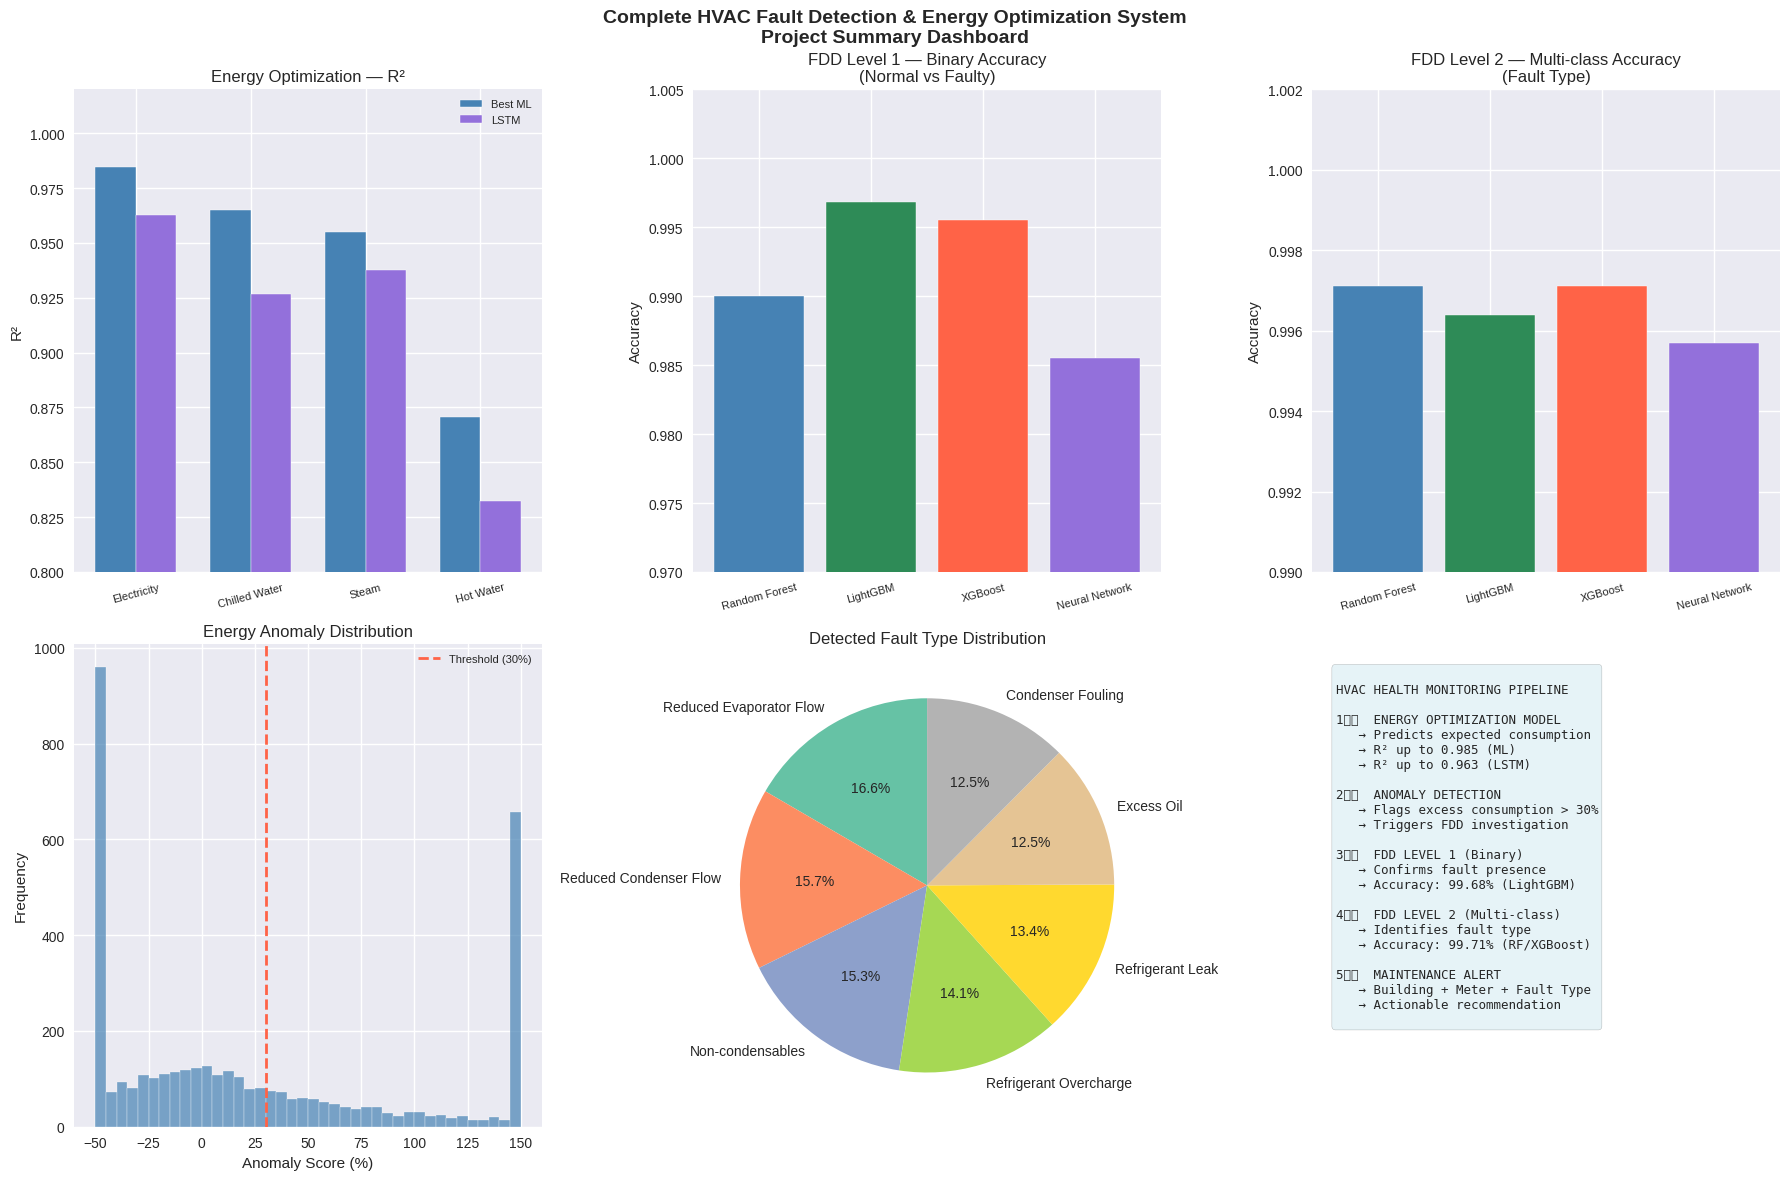

In [21]:
fig = plt.figure(figsize=(18, 12))

# --- Plot 1 — Energy Model R² ---
ax1 = fig.add_subplot(2, 3, 1)
meters  = energy_results['Meter']
ml_r2   = energy_results['ML R²']
lstm_r2 = energy_results['LSTM R²']

x     = np.arange(len(meters))
width = 0.35

ax1.bar(x - width/2, ml_r2,   width,
        label='Best ML', color='steelblue',
        edgecolor='white')
ax1.bar(x + width/2, lstm_r2, width,
        label='LSTM', color='mediumpurple',
        edgecolor='white')
ax1.set_title('Energy Optimization — R²')
ax1.set_ylabel('R²')
ax1.set_xticks(x)
ax1.set_xticklabels(meters, rotation=15, fontsize=8)
ax1.legend(fontsize=8)
ax1.set_ylim(0.8, 1.02)

# --- Plot 2 — FDD L1 Accuracy ---
ax2 = fig.add_subplot(2, 3, 2)
models_fdd = fdd_results['Model']
l1_acc     = fdd_results['L1 Accuracy']
colors_fdd = ['steelblue', 'seagreen',
              'tomato', 'mediumpurple']

ax2.bar(models_fdd, l1_acc,
        color=colors_fdd, edgecolor='white')
ax2.set_title('FDD Level 1 — Binary Accuracy\n'
              '(Normal vs Faulty)')
ax2.set_ylabel('Accuracy')
ax2.set_ylim(0.97, 1.005)
ax2.tick_params(axis='x', rotation=15, labelsize=8)

# --- Plot 3 — FDD L2 Accuracy ---
ax3 = fig.add_subplot(2, 3, 3)
l2_acc = fdd_results['L2 Accuracy']
ax3.bar(models_fdd, l2_acc,
        color=colors_fdd, edgecolor='white')
ax3.set_title('FDD Level 2 — Multi-class Accuracy\n'
              '(Fault Type)')
ax3.set_ylabel('Accuracy')
ax3.set_ylim(0.99, 1.002)
ax3.tick_params(axis='x', rotation=15, labelsize=8)

# --- Plot 4 — Anomaly Score Distribution ---
ax4 = fig.add_subplot(2, 3, 4)
ax4.hist(pred_df['anomaly_score'].clip(-50, 150),
         bins=40, color='steelblue',
         edgecolor='white', alpha=0.7)
ax4.axvline(x=anomaly_threshold,
            color='tomato', linewidth=2,
            linestyle='--',
            label=f'Threshold ({anomaly_threshold}%)')
ax4.set_title('Energy Anomaly Distribution')
ax4.set_xlabel('Anomaly Score (%)')
ax4.set_ylabel('Frequency')
ax4.legend(fontsize=8)

# --- Plot 5 — Fault Type Distribution ---
ax5 = fig.add_subplot(2, 3, 5)
if len(faulty_df) > 0:
    fault_counts = faulty_df['fault_name_pred']\
                             .value_counts()
    colors_pie   = plt.cm.Set2(
        np.linspace(0, 1, len(fault_counts)))
    ax5.pie(fault_counts.values,
            labels=fault_counts.index,
            colors=colors_pie,
            autopct='%1.1f%%',
            startangle=90)
    ax5.set_title('Detected Fault Type Distribution')

# --- Plot 6 — Pipeline Flow ---
ax6 = fig.add_subplot(2, 3, 6)
ax6.axis('off')

pipeline_text = """
HVAC HEALTH MONITORING PIPELINE

1️⃣  ENERGY OPTIMIZATION MODEL
   → Predicts expected consumption
   → R² up to 0.985 (ML)
   → R² up to 0.963 (LSTM)

2️⃣  ANOMALY DETECTION
   → Flags excess consumption > 30%
   → Triggers FDD investigation

3️⃣  FDD LEVEL 1 (Binary)
   → Confirms fault presence
   → Accuracy: 99.68% (LightGBM)

4️⃣  FDD LEVEL 2 (Multi-class)
   → Identifies fault type
   → Accuracy: 99.71% (RF/XGBoost)

5️⃣  MAINTENANCE ALERT
   → Building + Meter + Fault Type
   → Actionable recommendation
"""
ax6.text(0.05, 0.95, pipeline_text,
         transform=ax6.transAxes,
         fontsize=9, verticalalignment='top',
         fontfamily='monospace',
         bbox=dict(boxstyle='round',
                   facecolor='lightblue',
                   alpha=0.3))

plt.suptitle('Complete HVAC Fault Detection & '
             'Energy Optimization System\n'
             'Project Summary Dashboard',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [22]:
print("=" * 65)
print("FINAL PROJECT SUMMARY")
print("HVAC FAULT DETECTION & ENERGY OPTIMIZATION")
print("=" * 65)

print("""
DATASET USED:
  Energy Optimization : ASHRAE Great Energy Predictor III
                        Sites 14 & 15 | 4 meter types
                        4,316,560 rows | 16 features

  Fault Detection     : ASHRAE RP-1043 (Chiller Dataset)
                        11,000 rows | 16 sensor features
                        8 classes (1 Normal + 7 Fault types)

ENERGY OPTIMIZATION RESULTS:
  Best model per meter:
  ├── Electricity   : LightGBM | R²=0.985 | RMSE=15.88
  ├── Chilled Water : XGBoost  | R²=0.965 | RMSE=47.21
  ├── Steam         : RF       | R²=0.955 | RMSE=185.74
  └── Hot Water     : RF       | R²=0.871 | RMSE=305.71

  LSTM Performance:
  ├── Electricity   : R²=0.963
  ├── Chilled Water : R²=0.927
  ├── Steam         : R²=0.938
  └── Hot Water     : R²=0.833

FAULT DETECTION & DIAGNOSIS:
  Architecture : Hierarchical 2-Level System

  Cooling System (Chilled Water) — FULL FDD:
  ├── Level 1: LightGBM  | 99.68% accuracy
  ├── Level 2: RF/XGBoost| 99.71% accuracy
  └── 7 fault types diagnosed

  Heating Systems (Steam & Hot Water) — PARTIAL FDD:
  ├── Anomaly detection via energy model
  ├── Threshold: >30% excess consumption
  └── Manual inspection triggered on flag

  Limitation: No labeled fault dataset exists
  for heating system fault diagnosis
  Future Work: Extend FDD to boiler systems
  using ASHRAE RP-1312 or similar datasets

INTEGRATION PIPELINE:
  Energy model detects anomaly (>30% excess consumption)
       ↓
  FDD Level 1 confirms fault (99.68% accuracy)
       ↓
  FDD Level 2 diagnoses fault type (99.71% accuracy)
       ↓
  Maintenance alert generated with specific fault

KEY FINDINGS:
  1. Gradient boosting models outperform LSTM for
     tabular energy prediction data
  2. Lag features (1h, 24h, 7d) are the single most
     impactful feature for energy prediction
  3. Hierarchical FDD achieves near-perfect accuracy
     on ASHRAE RP-1043 controlled experiments
  4. Separate models per meter type significantly
     outperform combined models (R² +0.13 improvement)
  5. Energy anomaly detection provides effective trigger
     for FDD investigation
""")

print("✅ Project Complete!")

FINAL PROJECT SUMMARY
HVAC FAULT DETECTION & ENERGY OPTIMIZATION

DATASET USED:
  Energy Optimization : ASHRAE Great Energy Predictor III
                        Sites 14 & 15 | 4 meter types
                        4,316,560 rows | 16 features

  Fault Detection     : ASHRAE RP-1043 (Chiller Dataset)
                        11,000 rows | 16 sensor features
                        8 classes (1 Normal + 7 Fault types)

ENERGY OPTIMIZATION RESULTS:
  Best model per meter:
  ├── Electricity   : LightGBM | R²=0.985 | RMSE=15.88
  ├── Chilled Water : XGBoost  | R²=0.965 | RMSE=47.21
  ├── Steam         : RF       | R²=0.955 | RMSE=185.74
  └── Hot Water     : RF       | R²=0.871 | RMSE=305.71

  LSTM Performance:
  ├── Electricity   : R²=0.963
  ├── Chilled Water : R²=0.927
  ├── Steam         : R²=0.938
  └── Hot Water     : R²=0.833

FAULT DETECTION RESULTS (Hierarchical):
  Level 1 — Binary (Normal vs Faulty):
  ├── Best: LightGBM | Accuracy=99.68% | F1=0.9968
  └── NN:              Accu